# UnlimitedOCR C/Metal demo

Run the local C/Metal OCR engine on `docs/test.png`.

Prerequisites:
- a built `libunlimitedocr.dylib`
- `dist/unlimitedocr-fp16.uocr` exists
- a Metal-capable macOS machine

Library/resource resolution:
- if `UOCR_LIBRARY_PATH` is already set, the notebook uses it
- otherwise it prefers non-debug/precompiled build directories and falls back to `build/debug` only if needed
- if a precompiled `unlimitedocr.metallib` is present, the notebook points Metal resources at it

The first run can take several seconds while Metal resources and model views warm up.


In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'pyproject.toml').exists() and (ROOT.parent / 'pyproject.toml').exists():
    ROOT = ROOT.parent.resolve()

SRC_PATH = ROOT / 'src'
MODEL_PATH = ROOT / 'dist' / 'unlimitedocr-fp16.uocr'
IMAGE_PATH = ROOT / 'docs' / 'test.png'

def first_existing(paths):
    for path in paths:
        if path is not None and path.exists():
            return path
    return None

library_from_env = os.environ.get('UOCR_LIBRARY_PATH')
if library_from_env:
    LIBRARY_PATH = Path(library_from_env).expanduser().resolve()
else:
    LIBRARY_PATH = first_existing([
        ROOT / 'build' / 'release' / 'libunlimitedocr.dylib',
        ROOT / 'build' / 'release-qa' / 'libunlimitedocr.dylib',
        ROOT / 'build' / 'precompile' / 'libunlimitedocr.dylib',
        ROOT / 'build' / 'qa-precompiled' / 'libunlimitedocr.dylib',
        ROOT / 'build' / 'metal-no-rt' / 'libunlimitedocr.dylib',
        ROOT / 'build' / 'debug' / 'libunlimitedocr.dylib',
    ])
    if LIBRARY_PATH is None:
        raise FileNotFoundError('could not find libunlimitedocr.dylib; build the project or set UOCR_LIBRARY_PATH')

# Prefer the metallib that belongs to the selected library build. Do not
# accidentally pair a fresh library with a stale metallib from another build dir.
RESOURCE_PATH = None
selected_build_dir = LIBRARY_PATH.parent
if (selected_build_dir / 'unlimitedocr.metallib').exists():
    RESOURCE_PATH = selected_build_dir
elif (ROOT / 'build' / 'release' / 'unlimitedocr.metallib').exists() and selected_build_dir == ROOT / 'build' / 'release':
    RESOURCE_PATH = ROOT / 'build' / 'release'
else:
    RESOURCE_PATH = ROOT / 'src' / 'backend' / 'metal'
if not RESOURCE_PATH.exists():
    raise FileNotFoundError('could not find Metal resources; build a metallib or use src/backend/metal')

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Must be set before importing unlimitedocr_c.ffi / unlimitedocr_c.ocr.
os.environ['UOCR_LIBRARY_PATH'] = str(LIBRARY_PATH)

for path in (LIBRARY_PATH, MODEL_PATH, IMAGE_PATH, RESOURCE_PATH):
    if not path.exists():
        raise FileNotFoundError(path)

print('repo:', ROOT)
print('library:', LIBRARY_PATH)
print('model:', MODEL_PATH)
print('image:', IMAGE_PATH)
print('resources:', RESOURCE_PATH)


repo: /Users/mascit/projects/unlimitedocr.c
library: /Users/mascit/projects/unlimitedocr.c/build/release/libunlimitedocr.dylib
model: /Users/mascit/projects/unlimitedocr.c/dist/unlimitedocr-fp16.uocr
image: /Users/mascit/projects/unlimitedocr.c/docs/test.png
resources: /Users/mascit/projects/unlimitedocr.c/build/release


## Input image


(512, 193) RGBA


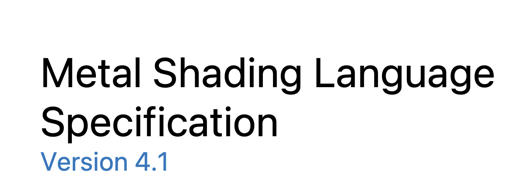

In [5]:
from IPython.display import display
from PIL import Image

image = Image.open(IMAGE_PATH)
image.thumbnail((512,512))
print(image.size, image.mode)
display(image)


## Run OCR

This uses `preset='base'` and a short generation cap so the demo completes quickly. Increase `max_gen_tokens` for longer outputs.


In [6]:
from time import perf_counter
from unlimitedocr_c.ocr import ocr_image

start = perf_counter()
result = ocr_image(
    str(IMAGE_PATH),
    model_path=str(MODEL_PATH),
    resource_path=str(RESOURCE_PATH),
    preset='base',
    max_length=4096,
    max_gen_tokens=64,
)
elapsed = perf_counter() - start

print(f'elapsed: {elapsed:.3f}s')
print(f'generated tokens: {len(result.token_ids)}')
print('token ids:', result.token_ids.tolist())
print('\ntext:')
print(result.text)


elapsed: 10.806s
generated tokens: 44
token ids: [128818, 10212, 764, 4610, 14, 223, 18085, 14, 223, 30898, 14, 223, 28723, 63, 128819, 108379, 2009, 11714, 10900, 201, 13613, 2886, 201, 128818, 2067, 764, 3045, 14, 223, 29979, 14, 223, 17922, 14, 223, 32908, 63, 128819, 22602, 223, 22, 16, 19, 1]

text:
<|det|>title [72, 279, 968, 752]<|/det|>Metal Shading Language
Specification
<|det|>text [77, 776, 331, 893]<|/det|>Version 4.1


## Optional: quick one-token smoke

Useful when checking that the engine, model, and Metal resources load correctly.


In [8]:
start = perf_counter()
smoke = ocr_image(
    str(IMAGE_PATH),
    model_path=str(MODEL_PATH),
    resource_path=str(RESOURCE_PATH),
    preset='base',
    max_length=4096,
    max_gen_tokens=1,
)
print(f'elapsed: {perf_counter() - start:.3f}s')
print(smoke.token_ids.tolist())
print(repr(smoke.text))


elapsed: 9.703s
[128818]
'<|det|>'
